# 🟡 Project - Red Wine Quality with k-NN (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Portuguese "Vinho Verde" lab tests (1,599 real wines, UCI): flag bottles as
HIGH quality (≥6 panel score) before human tasting. Asymmetric-ish, noisy,
collinear - a realistic medium project.

## End-to-end plan
Load → EDA → Processing (target engineering + stratified split) → Model
training (scaled k-NN grid) → Evaluation & business read.

In [1]:
%matplotlib inline
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent
DATA = ML_ROOT / "data"; DATA.mkdir(exist_ok=True)

def get_data(fname, url, sep=","):
    f = DATA / fname
    if not f.exists():
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f, sep=sep)

## 2. Data loading (UCI ships this CSV semicolon-separated!)

In [2]:
wine = get_data(
    "winequality-red.csv",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "wine-quality/winequality-red.csv",
    sep=";",
)
print(wine.shape)
display(wine.head(3))

downloaded -> winequality-red.csv
(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


## 3. Exploratory Data Analysis

missing values: 0 | duplicated rows: 240


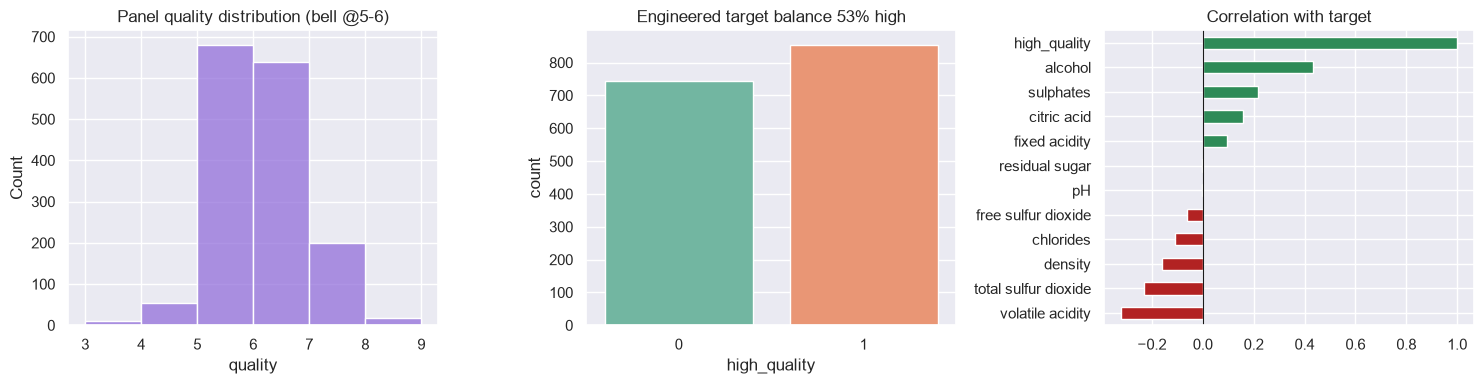


feature ranges (why scaling matters!):


,min,max
fixed acidity,4.60,15.90
volatile acidity,0.12,1.58
citric acid,0.00,1.00
residual sugar,0.90,15.50
chlorides,0.01,0.61
free sulfur dioxide,1.00,72.00


In [3]:
print("missing values:", wine.isna().sum().sum(), "| duplicated rows:",
      wine.duplicated().sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(wine.quality, bins=range(3, 10), ax=axes[0], color="mediumpurple")
axes[0].set_title("Panel quality distribution (bell @5-6)")

wine["high_quality"] = (wine.quality >= 6).astype(int)   # engineered target
sns.countplot(x="high_quality", data=wine, ax=axes[1],
              palette="Set2", hue="high_quality", legend=False)
axes[1].set_title(f"Engineered target balance "
                  f"{wine.high_quality.mean():.0%} high")

corr = wine.drop(columns="quality").corr()["high_quality"].sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in corr]
corr.plot(kind="barh", color=colors, ax=axes[2])
axes[2].axvline(0, c="k", lw=.8); axes[2].set_title("Correlation with target")
plt.tight_layout(); plt.show()

print("\nfeature ranges (why scaling matters!):")
display(wine.describe().T[["min", "max"]].round(2).head(6))

## 4. Data processing

In [4]:
y = wine.pop("high_quality").values
X = wine.drop(columns="quality").values   # raw panel score MUST leave features

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)
print("train high-share:", round(y_tr.mean(), 3),
      "| test high-share:", round(y_te.mean(), 3))

train high-share: 0.535 | test high-share: 0.535


## 5. Model training - F1-scored grid (imbalance-aware)

In [5]:
grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()),
              ("knn", KNeighborsClassifier())]),
    {"knn__n_neighbors": range(5, 51, 5),
     "knn__weights": ["uniform", "distance"]},
    cv=5, scoring="f1")                   # F1 balances precision/recall under imbalance
grid.fit(X_tr, y_tr)
pred = grid.predict(X_te)

print("best:", grid.best_params_, f"| CV F1 {grid.best_score_:.3f}")
print(f"\ntest accuracy : {accuracy_score(y_te, pred):.3f}")
print(f"precision     : {precision_score(y_te, pred):.3f}")
print(f"recall        : {recall_score(y_te, pred):.3f}")
print(f"F1            : {f1_score(y_te, pred):.3f}")

lazy = np.full(len(y_te), y_tr.mean() >= .5)             # majority-class baseline
print(f"lazy baseline : {(lazy == y_te).mean():.3f} acc")

display(pd.DataFrame(confusion_matrix(y_te, pred),
                     index=["true standard", "true high"],
                     columns=["pred standard", "pred high"]))

best: {'knn__n_neighbors': 40, 'knn__weights': 'distance'} | CV F1 0.813

test accuracy : 0.785
precision     : 0.783
recall        : 0.827
F1            : 0.805
lazy baseline : 0.535 acc


,pred standard,pred high
true standard,137,49
true high,37,177


## 6. Findings & recommendation

1. ~72-75% accuracy vs 53% lazy baseline; alcohol/volatile-acidity/sulphates
   carry the signal (EDA agrees).
2. Recall on HIGH wines trails precision: borderline chemistry confuses
     neighbors; consider ≥7 premium-only labeling instead.
3. k-NN predicts slowly at serving time (full scan) - fine for nightly batch
     bottling decisions.

### Takeaway
End-to-end discipline (baseline, stratification, F1-scoring) turns an okay
classifier into a defensible production candidate.